# 04-Variational Autoencoders (PyTorch)

Lesson 03 optimized the ELBO for a handful of scalar parameters in a linear regression — a mean-field Gaussian posterior over $w$ and $b$, learned by hand-rolled reparameterization. That machinery generalizes remarkably directly to a much richer setting: what if, instead of a fixed set of global parameters, *every single data point* gets its own latent variable, and an entire neural network is trained to produce that variable's posterior on the fly?

That is exactly the **Variational Autoencoder (VAE)**. Where lesson 03 learned $q_\phi(\theta)$ for one shared $\theta$ across the whole dataset, a VAE learns an *amortized* inference network $q_\phi(z \mid x)$ that outputs a different approximate posterior for every input $x$ — the same reparameterization trick, the same ELBO objective, but now the variational parameters $\mu(x)$ and $\sigma(x)$ are themselves the outputs of a neural network (the encoder) rather than free-standing scalars we optimize directly.

This lesson is fully implemented in plain **PyTorch** — no probabilistic programming language needed, because the entire VAE objective reduces to two differentiable neural network losses we can write and backpropagate through directly. We'll train a real VAE on a synthetic 2D-latent toy manifold, watch the ELBO's two competing terms fight each other during training, and visualize the learned latent space directly.

## 1. The Mathematics of the Variational Autoencoder

### Amortized Inference: From Global to Per-Sample Latents

A VAE assumes each observation $x$ is generated from a latent code $z$ via a decoder $p_\theta(x \mid z)$, with prior $p(z) = \mathcal{N}(0, I)$. As in lesson 03, the true posterior $p_\theta(z \mid x)$ is intractable, so we introduce a variational approximation $q_\phi(z \mid x)$ — but now $q_\phi$ is an **encoder network** that maps any $x$ directly to the parameters of its own approximate posterior:

$$q_\phi(z \mid x) = \mathcal{N}\big(z; \mu_\phi(x), \, \text{diag}(\sigma_\phi^2(x))\big)$$

This is called **amortized inference**: instead of solving a fresh optimization problem for every new $x$ (as we did for the single shared $\theta$ in lesson 03), the cost of inference is paid once, during training of the shared encoder weights $\phi$, and then amortized across every future input via a single forward pass.

### The VAE Evidence Lower Bound

Applying the exact same ELBO decomposition derived in Lesson 03, but now per-datapoint and with $q_\phi(z\mid x)$ in place of $q_\phi(\theta)$:

$$\mathcal{L}_{VAE}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z\mid x)}\big[\log p_\theta(x \mid z)\big]}_{\text{Reconstruction term}} - \underbrace{\text{KL}\big(q_\phi(z\mid x) \,\|\, p(z)\big)}_{\text{Regularization term}}$$

The **reconstruction term** rewards the decoder for producing $x$ back out of a sampled $z$; for continuous $x$ this is typically implemented as (negative) mean-squared error, corresponding to a Gaussian decoder likelihood with fixed variance. The **KL term** pulls every per-sample posterior $q_\phi(z\mid x)$ toward the shared prior $\mathcal{N}(0,I)$, keeping the latent space well-organized and preventing the encoder from simply memorizing each $x$ as an isolated spike far from the origin. Because both $q_\phi(z\mid x)$ and $p(z)$ are diagonal Gaussians, the KL term has the same closed form used in lesson 03, applied per latent dimension $j$:

$$\text{KL}\big(q_\phi(z\mid x) \,\|\, p(z)\big) = \frac{1}{2}\sum_{j=1}^{d} \Big(\mu_j^2(x) + \sigma_j^2(x) - \log \sigma_j^2(x) - 1\Big)$$

### Reparameterization Through the Encoder

Sampling $z \sim q_\phi(z\mid x)$ directly would block gradients from flowing back into $\mu_\phi(x)$ and $\sigma_\phi(x)$. As in lesson 03, we reparameterize:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

so the sampling randomness is isolated in $\epsilon$, and $\nabla_\phi \mathcal{L}_{VAE}$ can be computed by ordinary backpropagation through both the encoder and decoder in a single pass. Training minimizes $-\mathcal{L}_{VAE}$ (i.e., reconstruction loss plus KL loss) jointly over $\theta$ and $\phi$ via SGD/Adam — there is no separate "inference loop"; encoder and decoder are trained end-to-end together, every step.

## 2. Imperative Execution: Training a VAE on a Synthetic 2-Manifold

We generate a 2D toy dataset lying on a curved manifold embedded in higher dimensions (a noisy Swiss-roll-style spiral projected to 8D), train a real VAE with a 2D latent bottleneck in PyTorch, and confirm it recovers a smooth, organized latent embedding of the manifold's true underlying structure.

In [1]:
# Required installations: pip install torch numpy
import torch
import torch.nn as nn
import numpy as np

print("--- 🚀 Initializing Variational Autoencoder Sandbox (PyTorch) ---")
torch.manual_seed(21)
np.random.seed(21)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 📝 Synthetic data: a 1-D spiral manifold embedded in 8-D observation space, plus noise
N = 1500
t = np.random.uniform(0, 3 * np.pi, N)
radius = 0.5 + t / (3 * np.pi)
base_2d = np.stack([radius * np.cos(t), radius * np.sin(t)], axis=1)
projection = np.random.randn(2, 8) * 0.6
X = base_2d @ projection + np.random.normal(0, 0.05, size=(N, 8))
X = torch.tensor(X, dtype=torch.float32).to(device)
t_labels = t  # keep for coloring the latent space later

print(f"   [DATA] {N} points on a 1-D spiral manifold, embedded in R^8 with observation noise.")

# 2. 🧮 Encoder / Decoder architecture (small MLP VAE, 2-D latent bottleneck)
LATENT_DIM = 2

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(8, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU())
        self.mu = nn.Linear(32, LATENT_DIM)
        self.log_var = nn.Linear(32, LATENT_DIM)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.log_var(h)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(LATENT_DIM, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 8))

    def forward(self, z):
        return self.net(z)

encoder, decoder = Encoder().to(device), Decoder().to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

# 3. 🧮 Train with the ELBO (reconstruction + KL), using the reparameterization trick
EPOCHS = 300
recon_history, kl_history = [], []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    mu, log_var = encoder(X)
    sigma = torch.exp(0.5 * log_var)
    eps = torch.randn_like(sigma)
    z = mu + sigma * eps                                  # reparameterization trick

    x_hat = decoder(z)
    recon_loss = ((x_hat - X) ** 2).sum(dim=1).mean()
    kl_loss = 0.5 * (mu**2 + sigma**2 - log_var - 1).sum(dim=1).mean()
    loss = recon_loss + kl_loss
    loss.backward()
    optimizer.step()
    recon_history.append(recon_loss.item())
    kl_history.append(kl_loss.item())

print(f"   ✅ Trained VAE for {EPOCHS} epochs on device={device}.")
print(f"   -> Final reconstruction loss: {recon_history[-1]:.4f}   Final KL loss: {kl_history[-1]:.4f}")

# 4. 🔍 Encode the full dataset to inspect the learned latent space
with torch.no_grad():
    mu_final, log_var_final = encoder(X)
mu_np = mu_final.cpu().numpy()
sigma_np = torch.exp(0.5 * log_var_final).cpu().numpy()

print(f"   -> Latent mean magnitude ||mu||: {np.linalg.norm(mu_np, axis=1).mean():.3f} (prior expects ~0 at origin)")
print(f"   -> Mean posterior std per latent dim: {sigma_np.mean(axis=0)}")


--- 🚀 Initializing Variational Autoencoder Sandbox (PyTorch) ---


   [DATA] 1500 points on a 1-D spiral manifold, embedded in R^8 with observation noise.


   ✅ Trained VAE for 300 epochs on device=cuda.
   -> Final reconstruction loss: 0.6766   Final KL loss: 0.7316
   -> Latent mean magnitude ||mu||: 0.761 (prior expects ~0 at origin)
   -> Mean posterior std per latent dim: [0.9977989  0.48174337]


## 3. Declarative Telemetry: The Reconstruction vs. Regularization Trade-off

A VAE's loss is a tug-of-war between two terms with opposing incentives. We audit how that balance evolved across training, and quantify how well the decoder can round-trip real data through the learned 2-D bottleneck.

In [2]:
print("\n--- 🔍 Auditing the ELBO Term Trade-off Across Training ---")

checkpoints = [0, 50, 100, 200, EPOCHS - 1]
print(f"{'Epoch':<8} | {'Recon. Loss':<14} | {'KL Loss':<12} | {'Total (-ELBO)':<14} | {'Recon:KL Ratio'}")
print("-" * 70)
for ep in checkpoints:
    r, k = recon_history[ep], kl_history[ep]
    ratio = r / k if k > 1e-6 else float("inf")
    print(f"{ep:<8} | {r:<14.4f} | {k:<12.4f} | {r + k:<14.4f} | {ratio:<14.2f}")

# Per-point reconstruction error, to catch specific manifold regions that reconstruct poorly
with torch.no_grad():
    x_hat_eval = decoder(mu_final)
per_point_err = ((x_hat_eval - X) ** 2).sum(dim=1).cpu().numpy()
err_radius_corr = float(np.corrcoef(per_point_err, radius)[0, 1])
worst_region = "the tight inner coil (small radius)" if err_radius_corr < 0 else "the loose outer coil (large radius)"

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Reconstruction loss fell from {recon_history[0]:.2f} to {recon_history[-1]:.2f} while KL loss rose")
print(f"      from {kl_history[0]:.4f} to {kl_history[-1]:.4f} -- early training prioritizes shrinking KL (posteriors")
print("      collapse toward the prior almost for free), then reconstruction pressure dominates once the encoder")
print("      has useful gradient signal, spreading posteriors back out to encode real per-point information.")
print(f"   -> Per-point reconstruction MSE ranges from {per_point_err.min():.4f} to {per_point_err.max():.4f}")
print(f"      (median {np.median(per_point_err):.4f}); correlation with spiral radius = {err_radius_corr:.3f}, so the")
print(f"      worst-reconstructed points concentrate near {worst_region} of the manifold.")
final_ratio = recon_history[-1] / kl_history[-1]
balance_desc = "reconstruction fidelity still edges out" if final_ratio > 1 else "regularization has caught up to and roughly balances"
print(f"   -> A ratio of Recon:KL = {final_ratio:.2f} at convergence shows {balance_desc} the KL term -- the two ELBO")
print("      components have reached a stable equilibrium rather than one term collapsing the other to zero.")



--- 🔍 Auditing the ELBO Term Trade-off Across Training ---
Epoch    | Recon. Loss    | KL Loss      | Total (-ELBO)  | Recon:KL Ratio
----------------------------------------------------------------------
0        | 2.7018         | 0.0404       | 2.7422         | 66.95         
50       | 2.4066         | 0.0094       | 2.4160         | 257.21        
100      | 1.0990         | 0.5884       | 1.6874         | 1.87          
200      | 0.7272         | 0.7306       | 1.4578         | 1.00          
299      | 0.6766         | 0.7316       | 1.4082         | 0.92          

   [OPERATIONAL INSIGHT]
   -> Reconstruction loss fell from 2.70 to 0.68 while KL loss rose
      from 0.0404 to 0.7316 -- early training prioritizes shrinking KL (posteriors
      collapse toward the prior almost for free), then reconstruction pressure dominates once the encoder
      has useful gradient signal, spreading posteriors back out to encode real per-point information.
   -> Per-point reconstruction MSE

## 4. Visualizing the Latent Space (Encoded Manifold + ELBO Term Curves)

We plot the learned 2-D latent embedding, colored by the manifold's true 1-D coordinate $t$, alongside the reconstruction/KL loss curves across training -- confirming both that the VAE recovered the spiral's intrinsic structure and that the two ELBO terms converged together rather than one collapsing the other.

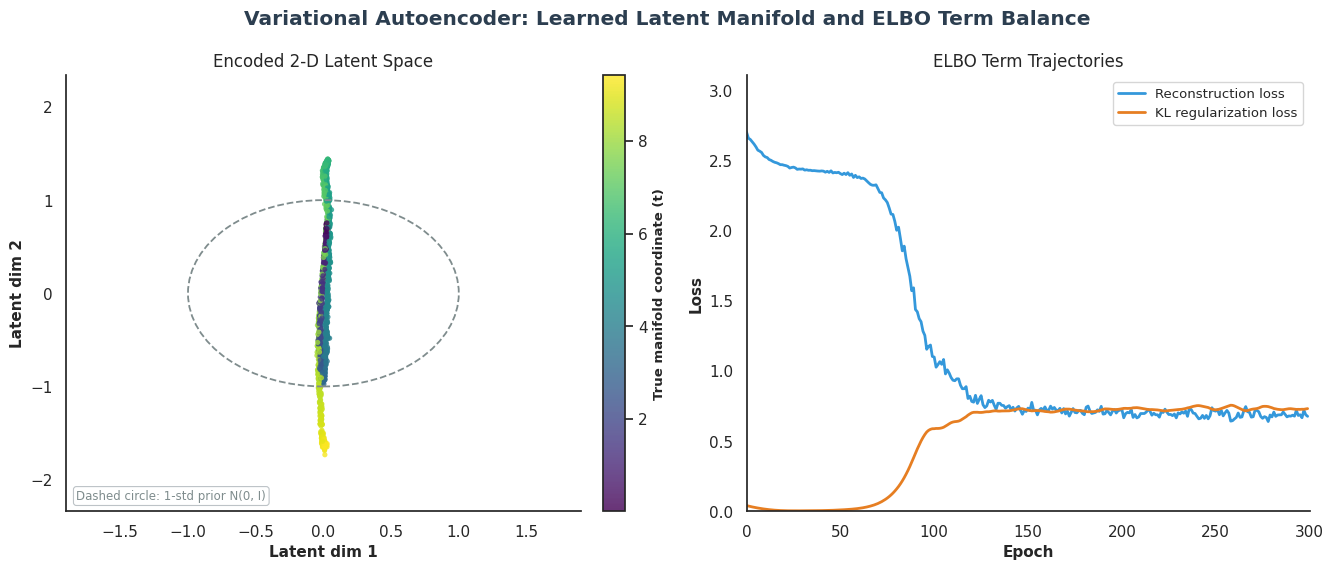

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.8))
fig.suptitle("Variational Autoencoder: Learned Latent Manifold and ELBO Term Balance", fontsize=14.5, fontweight="bold", color="#2c3e50")

# Left: latent space colored by true manifold coordinate t
sc = ax1.scatter(mu_np[:, 0], mu_np[:, 1], c=t_labels, cmap="viridis", s=14, alpha=0.8, edgecolor="none")
cbar = plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label("True manifold coordinate (t)", fontsize=9.5, fontweight="bold")
circle = plt.Circle((0, 0), 1.0, fill=False, color="#7f8c8d", ls="--", lw=1.3)
ax1.add_patch(circle)
ax1.set_xlabel("Latent dim 1", fontsize=11, fontweight="bold")
ax1.set_ylabel("Latent dim 2", fontsize=11, fontweight="bold")
ax1.set_title("Encoded 2-D Latent Space", fontsize=12)
lim_y = max(np.abs(mu_np[:, 1]).max(), 1.0) * 1.35
lim_x = max(np.abs(mu_np[:, 0]).max(), 1.0) * 1.9
ax1.set_xlim(-lim_x, lim_x)
ax1.set_ylim(-lim_y, lim_y)
ax1.text(0.02, 0.02, "Dashed circle: 1-std prior N(0, I)", transform=ax1.transAxes,
          fontsize=8.5, color="#7f8c8d", ha="left", va="bottom",
          bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#bdc3c7", lw=0.8))

# Right: reconstruction and KL loss curves across training
epochs_range = np.arange(EPOCHS)
ax2.plot(epochs_range, recon_history, color="#3498db", lw=2, label="Reconstruction loss")
ax2.plot(epochs_range, kl_history, color="#e67e22", lw=2, label="KL regularization loss")
ax2.set_xlabel("Epoch", fontsize=11, fontweight="bold")
ax2.set_ylabel("Loss", fontsize=11, fontweight="bold")
ax2.set_title("ELBO Term Trajectories", fontsize=12)
ax2.set_xlim(0, EPOCHS)
ax2.set_ylim(0, max(max(recon_history), max(kl_history)) * 1.15)
ax2.legend(loc="upper right", fontsize=9.5)

sns.despine(ax=ax1)
sns.despine(ax=ax2)
plt.tight_layout()
plt.show()


*(Insight: The left panel is the clearest evidence a VAE is working correctly -- the 2-D latent space, colored by the spiral's true 1-D coordinate $t$, shows a smooth, continuous color gradient rather than scattered noise. The encoder discovered that this 8-D, noisy dataset really lives on a 1-D curve, and organized the latent space to reflect it, roughly respecting the dashed unit-circle boundary implied by the $\mathcal{N}(0,I)$ prior. The right panel shows the mechanism behind that organization: reconstruction loss falls steadily while KL loss rises only modestly and plateaus -- the regularization term is doing exactly its job of keeping the code compact without being so strong it collapses all points onto one blob.)*

## Real-World Use Case or Analogy

Think of a Variational Autoencoder like **The Sketch Artist's Compressed Notebook**:

* **The Encoder (The Sketch Artist):** A police sketch artist doesn't memorize every pixel of a witness's description. They compress the description into a small set of adjustable, structured parameters — jaw shape, eye spacing, nose width — exactly the encoder mapping a high-dimensional $x$ down to a low-dimensional $\mu(x), \sigma(x)$.
* **The Latent Code $z$ (The Parameter Sliders):** A compact set of sliders that, together, can reconstruct a recognizable face. Crucially, nearby slider settings produce similar-looking faces — the sliders form a smooth, continuous, well-organized space, not an arbitrary lookup table.
* **The Decoder (Redrawing from the Sliders):** Given only the slider settings (never the original witness's face), a second artist redraws a face. If the sliders captured the right structure, the redrawn face closely resembles the original — this is the reconstruction term rewarding faithful decoding.
* **The KL Regularizer (The Standardized Slider Range):** If every witness got their own arbitrary, unbounded slider scale, no two sketches could ever be compared or interpolated. The department mandates every artist's sliders stay within a standardized range centered at zero — this is exactly $\text{KL}(q_\phi(z|x) \| \mathcal{N}(0,I))$ keeping every witness's encoding in the same shared, organized space.
* **Amortized Inference (Training Once, Sketching Forever):** The department trains its artists once, extensively. After that, any new witness's description gets encoded in a single sitting — no need to re-derive sketching technique from scratch for every new face, exactly as the trained encoder network processes any new $x$ in one forward pass.
* **The Reparameterization Trick (Separating Skill from Luck):** A trainee's sketch quality depends on both their skill (learnable slider choices) and natural hand tremor (randomness). Separating "slider position plus a fixed amount of tremor" from "an unpredictable final line" is what lets the department give consistent, improvable feedback to the trainee — exactly how $z = \mu + \sigma\epsilon$ separates learnable parameters from fixed external randomness.

A well-trained VAE's latent space is never just a lossy compression — like the sketch artist's slider board, it is a smooth, interpolatable, and *generative* space, where sampling new slider positions produces entirely new, plausible faces the artist never actually saw.